
# Patient visualization workbench v3
## `open_hand` vs `all_other_gestures`

Ноутбук строит базовые raw/ERP-визуализации и затем закрывает текущие задачи:

1. две версии TFR: абсолютная лог-мощность без baseline correction и pipeline-like вариант с baseline `(-0.1, 0.0)` относительно LSL-метки;
2. разложение pooled negative class по девяти отдельным жестам;
3. количественные карты различимости по времени и частоте: Cohen's d и ROC-AUC;
4. выделение фактического decoder window: `0.0–1.0 s` относительно LSL-метки и `0.1–59.4 Hz`.

Анализ переходов между жестами намеренно не выполняется: структура чередования известна из экспериментальной парадигмы.



## 0. Параметры

В этом блоке меняются основные настройки:

- `PATIENT_ID` — пациент, которого смотришь;
- `STUDY_DEF_PATH` — путь к папке `study_definition_open_vs_all` **или** к zip-архиву;
- `DATA_ROOT` — корень датасета с EDF;
- `OUTPUT_ROOT` — куда сохранять картинки;
- `SESSIONS_TO_USE` — `None` для всех сессий пациента или список конкретных сессий;
- `PLOT_TMIN_ROBOT`, `PLOT_TMAX_ROBOT` — окно визуализации относительно **начала движения робота**;
- `ROBOT_DELAY_S` — задержка между LSL-меткой и началом движения робота.


In [8]:

from pathlib import Path

# ======== WHAT TO LOOK AT ========
PATIENT_ID = 's11'
SESSIONS_TO_USE = None  # None -> all sessions of the patient; or e.g. ['2025-09-02_s11/session_1']

# ======== INPUTS ========
STUDY_DEF_PATH = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/study_definition_open_vs_all')  # folder or .zip
DATA_ROOT = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PirogovDATA')

# ======== OUTPUTS ========
OUTPUT_ROOT = Path('/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs') / PATIENT_ID

# ======== TIMING ========
ROBOT_DELAY_S = 0.100  # confirmed approximation used in the current project
PLOT_TMIN_ROBOT = -1.0
PLOT_TMAX_ROBOT = 2.0

DECODER_TMIN_MARKER = 0.0
DECODER_TMAX_MARKER = 1.0

DECODER_FMIN = 0.1
DECODER_FMAX = 59.4

DECODER_TMIN_ROBOT = DECODER_TMIN_MARKER - ROBOT_DELAY_S
DECODER_TMAX_ROBOT = DECODER_TMAX_MARKER - ROBOT_DELAY_S
# Internally, epochs are cut relative to the LSL marker.
# If robot onset = marker + 0.1 s, then [-1, +2] relative to robot
# becomes [-0.9, +2.1] relative to the marker.
EPOCH_TMIN_MARKER = PLOT_TMIN_ROBOT + ROBOT_DELAY_S
EPOCH_TMAX_MARKER = PLOT_TMAX_ROBOT + ROBOT_DELAY_S

# ======== PREPROCESSING ========
NOTCH_FREQS = [50, 100, 150]
L_FREQ = 0.1
H_FREQ = 120.0


# ======== TFR ========
TFR_FMIN = 0.1
TFR_FMAX = 120.0
TFR_N_FREQS = 100
TFR_DECIM = 2
TFR_BASELINE = (-1.0, -0.2)  # relative to robot onset, used only for TFR normalization
TFR_BASELINE_MODE = 'logratio'  # 'logratio', 'percent', 'zscore', or None

# ======== SAVING / PLOTTING ========
FIG_DPI = 160
SAVE_PNG = True
SAVE_SVG = False
SHOW_INLINE_PREVIEW = True
MAX_CHANNELS_PER_FIGURE = 8  # used for channel-grid TFR figures


## Временная система координат на всех новых графиках

Чтобы исключить двусмысленность, основная ось X теперь всегда показывает **время относительно LSL-метки**:

- пунктирная линия: **LSL marker, 0.0 s**;
- штрих-пунктирная линия: **фактическое начало движения робота, +0.1 s**;
- серый интервал / прямоугольник: **фактический вход декодера, 0–1 s от LSL-метки**;
- этот же decoder window соответствует **−0.1…0.9 s относительно начала движения робота**.

Также исправлено преобразование границ окна: диапазон `−1…+2 s` относительно начала движения робота соответствует `−0.9…+2.1 s` относительно LSL-метки.


## 1. Импорты и служебные функции

In [2]:
import io
import json
import math
import zipfile
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = FIG_DPI
plt.rcParams['savefig.dpi'] = FIG_DPI
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def split_retained_channels(s: str):
    if pd.isna(s) or not str(s).strip():
        return []
    return [x for x in str(s).split('|') if x]


def load_table(study_def_path: Path, relative_path: str) -> pd.DataFrame:
    if study_def_path.is_dir():
        return pd.read_csv(study_def_path / relative_path)
    if study_def_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(study_def_path, 'r') as zf:
            target = None
            for name in zf.namelist():
                if name.endswith('/' + relative_path) or name == relative_path:
                    target = name
                    break
            if target is None:
                raise FileNotFoundError(f'Cannot find {relative_path} inside {study_def_path}')
            with zf.open(target) as f:
                return pd.read_csv(f)
    raise ValueError(f'Unsupported STUDY_DEF_PATH: {study_def_path}')


def load_json(study_def_path: Path, relative_path: str):
    if study_def_path.is_dir():
        with open(study_def_path / relative_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    if study_def_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(study_def_path, 'r') as zf:
            target = None
            for name in zf.namelist():
                if name.endswith('/' + relative_path) or name == relative_path:
                    target = name
                    break
            if target is None:
                raise FileNotFoundError(f'Cannot find {relative_path} inside {study_def_path}')
            with zf.open(target) as f:
                return json.load(io.TextIOWrapper(f, encoding='utf-8'))
    raise ValueError(f'Unsupported STUDY_DEF_PATH: {study_def_path}')


def save_figure(fig, out_path: Path):
    if SAVE_PNG:
        fig.savefig(out_path.with_suffix('.png'), bbox_inches='tight')
    if SAVE_SVG:
        fig.savefig(out_path.with_suffix('.svg'), bbox_inches='tight')
    plt.close(fig)


def sanitize_session_name(session_name: str) -> str:
    return session_name.replace('/', '__').replace(' ', '_')


def robust_vlim(x, q=0.995):
    x = np.asarray(x)
    if x.size == 0:
        return 1.0
    return float(np.nanquantile(np.abs(x), q))


def build_event_array(df_session: pd.DataFrame, class_to_code: dict[str, int]):
    accepted = df_session[df_session['accepted_after_rejection'] == True].copy()
    accepted = accepted[accepted['class_name'].isin(class_to_code.keys())].copy()
    accepted = accepted.sort_values(['sample', 'annotation_index']).reset_index(drop=True)
    events = np.zeros((len(accepted), 3), dtype=int)
    events[:, 0] = accepted['sample'].astype(int).to_numpy()
    events[:, 2] = accepted['class_name'].map(class_to_code).astype(int).to_numpy()
    return accepted, events


def preprocess_raw_for_retained_channels(raw: mne.io.BaseRaw, retained_channels: list[str]):
    raw = raw.copy().pick(retained_channels)
    raw.notch_filter(NOTCH_FREQS, verbose='ERROR')
    raw.filter(L_FREQ, H_FREQ, verbose='ERROR')
    raw.set_eeg_reference(ref_channels='average', verbose='ERROR')
    return raw


def build_epochs_for_session(session_df: pd.DataFrame, class_to_code: dict[str, int]):
    edf_path = Path(session_df['edf_path'].iloc[0])
    retained_channels = split_retained_channels(session_df['retained_channels'].iloc[0])
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw = preprocess_raw_for_retained_channels(raw, retained_channels)

    accepted_df, events = build_event_array(session_df, class_to_code)
    if len(events) == 0:
        raise RuntimeError(f'No accepted task epochs found for session {session_df["session"].iloc[0]}')

    event_id = {k: v for k, v in class_to_code.items()}
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=EPOCH_TMIN_MARKER,
        tmax=EPOCH_TMAX_MARKER,
        baseline=None,
        preload=True,
        verbose='ERROR',
    )
    return raw, epochs, accepted_df, retained_channels


def marker_time_axis(epochs: mne.Epochs):
    """Primary plotting axis: time relative to the LSL marker."""
    return epochs.times


def class_epoch_mean(epochs: mne.Epochs, class_name: str):
    data = epochs[class_name].get_data()  # (n_epochs, n_channels, n_times)
    return data.mean(axis=0)


def plot_all_channel_mean_heatmaps(epochs, patient_id, session_name, out_path: Path):
    times = marker_time_axis(epochs)
    open_mean = class_epoch_mean(epochs, 'open_hand')
    other_mean = class_epoch_mean(epochs, 'all_other_gestures')
    diff_mean = open_mean - other_mean
    channels = epochs.ch_names

    v = max(robust_vlim(open_mean), robust_vlim(other_mean), robust_vlim(diff_mean))

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(channels) * 0.35)), constrained_layout=True)
    for ax, arr, title in zip(
        axes,
        [open_mean, other_mean, diff_mean],
        ['open_hand mean', 'all_other_gestures mean', 'difference (open - other)'],
    ):
        im = ax.imshow(
            arr,
            aspect='auto',
            origin='lower',
            extent=[times[0], times[-1], -0.5, len(channels) - 0.5],
            cmap='RdBu_r',
            vmin=-v,
            vmax=v,
            interpolation='nearest',
            resample=False,
        )
        add_event_timing_lines(ax, decoder_span=True)
        ax.set_title(title)
        ax.set_xlabel('Time from LSL marker (s)')
        ax.set_yticks(np.arange(len(channels)))
        ax.set_yticklabels(channels)
        for y in np.arange(0.5, len(channels), 1):
            ax.axhline(y, color='black', linewidth=0.25, alpha=0.25)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    axes[0].set_ylabel('Retained channels')
    fig.suptitle(
        f'{patient_id} | {session_name} | all-channel mean heatmaps\n'
        + timing_caption()
    )
    axes[0].legend(
        handles=timing_legend_handles(include_decoder=True),
        loc='upper right',
        framealpha=0.9,
    )
    save_figure(fig, out_path)


def plot_channel_overlay_grid(epochs, patient_id, session_name, out_path: Path):
    times = marker_time_axis(epochs)
    open_mean = class_epoch_mean(epochs, 'open_hand')
    other_mean = class_epoch_mean(epochs, 'all_other_gestures')
    channels = epochs.ch_names
    n = len(channels)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(3, nrows * 2.4)), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    ylim = robust_vlim(np.concatenate([open_mean, other_mean], axis=0))
    for i, ch in enumerate(channels):
        ax = axes[i]
        ax.plot(times, open_mean[i], label='open_hand', linewidth=1.5)
        ax.plot(times, other_mean[i], label='all_other_gestures', linewidth=1.2)
        add_event_timing_lines(ax, decoder_span=True)
        ax.set_title(ch)
        ax.set_ylim(-ylim, ylim)
        ax.set_xlabel('Time from LSL marker (s)')
        ax.set_ylabel('Amplitude')
        if i == 0:
            class_handles, class_labels = ax.get_legend_handles_labels()
            ax.legend(
                handles=class_handles + timing_legend_handles(include_decoder=True),
                labels=class_labels + [h.get_label() for h in timing_legend_handles(include_decoder=True)],
                loc='upper right',
                framealpha=0.9,
            )
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(
        f'{patient_id} | {session_name} | per-channel class means\n'
        + timing_caption()
    )
    save_figure(fig, out_path)


def compute_mean_tfr(epochs, class_name: str):
    freqs = np.linspace(TFR_FMIN, TFR_FMAX, TFR_N_FREQS)
    n_cycles = freqs / 2.0
    tfr = mne.time_frequency.tfr_morlet(
        epochs[class_name],
        freqs=freqs,
        n_cycles=n_cycles,
        use_fft=True,
        return_itc=False,
        average=True,
        decim=TFR_DECIM,
        n_jobs=1,
        verbose='ERROR',
    )
    if TFR_BASELINE_MODE is not None:
        tfr.apply_baseline((TFR_BASELINE[0] + ROBOT_DELAY_S, TFR_BASELINE[1] + ROBOT_DELAY_S), mode=TFR_BASELINE_MODE)
    return tfr


def plot_tfr_channel_pages(tfr_open, tfr_other, patient_id, session_name, out_dir: Path, prefix: str):
    times = tfr_open.times
    freqs = tfr_open.freqs
    channels = tfr_open.ch_names
    diff = tfr_open.data - tfr_other.data

    n_ch = len(channels)
    n_pages = math.ceil(n_ch / MAX_CHANNELS_PER_FIGURE)
    for page_idx in range(n_pages):
        ch_start = page_idx * MAX_CHANNELS_PER_FIGURE
        ch_end = min((page_idx + 1) * MAX_CHANNELS_PER_FIGURE, n_ch)
        subset = list(range(ch_start, ch_end))
        nrows = len(subset)
        fig, axes = plt.subplots(nrows, 3, figsize=(15, max(3, nrows * 2.7)), constrained_layout=True)
        if nrows == 1:
            axes = np.expand_dims(axes, axis=0)

        v = max(
            robust_vlim(tfr_open.data[subset]),
            robust_vlim(tfr_other.data[subset]),
            robust_vlim(diff[subset]),
        )
        for row, ch_idx in enumerate(subset):
            ch_name = channels[ch_idx]
            panels = [tfr_open.data[ch_idx], tfr_other.data[ch_idx], diff[ch_idx]]
            titles = [f'{ch_name} | open_hand', f'{ch_name} | all_other', f'{ch_name} | diff']
            for col in range(3):
                ax = axes[row, col]
                im = ax.imshow(
                    panels[col], aspect='auto', origin='lower',
                    extent=[times[0], times[-1], freqs[0], freqs[-1]],
                    cmap='RdBu_r', vmin=-v, vmax=v,
                )
                add_event_timing_lines(ax, decoder_span=True)
                ax.set_title(titles[col])
                ax.set_xlabel('Time from LSL marker (s)')
                ax.set_ylabel('Frequency (Hz)')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        fig.suptitle(f'{patient_id} | {session_name} | TFR page {page_idx+1}/{n_pages}')
        save_figure(fig, out_dir / f'{prefix}__tfr_page_{page_idx+1:02d}')


def aggregate_epochs(epoch_list: list[mne.Epochs]) -> mne.Epochs:
    # Each recording session starts event sample numbering from zero,
    # so identical sample indices can occur in different sessions.
    # add_offset=True shifts event indices between sessions only for bookkeeping;
    # it does not change epoch data or the time axis inside each epoch.
    return mne.concatenate_epochs(epoch_list, add_offset=True)


def write_text_summary(path: Path, text: str):
    path.write_text(text, encoding='utf-8')

In [6]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle


# Время задаётся относительно LSL-метки
ROBOT_ONSET_MARKER_TIME = ROBOT_DELAY_S  # +0.1 s


def add_event_timing_lines(ax, *, decoder_span: bool = False) -> None:
    """
    Добавляет обозначения событий на график.

    Ось X:
    - 0.0 s — LSL-метка;
    - +0.1 s — фактическое начало движения робота;
    - 0.0–1.0 s — интервал, поступавший в декодер.
    """
    # LSL marker
    ax.axvline(
        DECODER_TMIN_MARKER,
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=10,
    )

    # Robot movement onset
    ax.axvline(
        ROBOT_ONSET_MARKER_TIME,
        color="black",
        linestyle="-.",
        linewidth=1.2,
        alpha=0.8,
        zorder=10,
    )

    if decoder_span:
        ax.axvspan(
            DECODER_TMIN_MARKER,
            DECODER_TMAX_MARKER,
            color="grey",
            alpha=0.08,
            zorder=0,
        )


def timing_legend_handles(*, include_decoder: bool = True):
    handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="LSL marker (0 s)",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-.",
            linewidth=1.2,
            alpha=0.8,
            label=f"Robot movement onset (+{ROBOT_DELAY_S:.1f} s)",
        ),
    ]

    if include_decoder:
        handles.append(
            Patch(
                facecolor="grey",
                edgecolor="none",
                alpha=0.12,
                label="Decoder input: 0–1 s from LSL marker",
            )
        )

    return handles


def timing_caption() -> str:
    return (
        f"LSL marker = 0 s; robot onset = +{ROBOT_DELAY_S:.1f} s; "
        "decoder input = 0–1 s from marker "
        f"({DECODER_TMIN_ROBOT:.1f}–{DECODER_TMAX_ROBOT:.1f} s "
        "relative to robot onset)"
    )


def add_decoder_window(ax) -> None:
    """Выделяет частотно-временной прямоугольник входа декодера."""
    rectangle = Rectangle(
        (DECODER_TMIN_MARKER, DECODER_FMIN),
        DECODER_TMAX_MARKER - DECODER_TMIN_MARKER,
        DECODER_FMAX - DECODER_FMIN,
        fill=False,
        edgecolor="black",
        linewidth=1.3,
        linestyle="--",
        zorder=11,
    )
    ax.add_patch(rectangle)

## 2. Загрузка `study_definition`, отбор пациента и подготовка структуры папок

In [3]:

manifest = load_table(STUDY_DEF_PATH, 'sample_manifest.csv')
session_summary = load_table(STUDY_DEF_PATH, 'session_summary.csv')
class_counts_wide = load_table(STUDY_DEF_PATH, 'class_counts_wide.csv')
gesture_mapping = load_table(STUDY_DEF_PATH, 'gesture_mapping.csv')
task_config = load_json(STUDY_DEF_PATH, 'task_config.resolved.json')

manifest['accepted_after_rejection'] = manifest['accepted_after_rejection'].astype(str).str.lower().map({'true': True, 'false': False})
manifest['included_in_main_task'] = manifest['included_in_main_task'].astype(str).str.lower().map({'true': True, 'false': False})

patient_manifest = manifest[manifest['subject'] == PATIENT_ID].copy()
if SESSIONS_TO_USE is not None:
    patient_manifest = patient_manifest[patient_manifest['session'].isin(SESSIONS_TO_USE)].copy()

if patient_manifest.empty:
    raise ValueError(f'No rows found for patient {PATIENT_ID} with sessions {SESSIONS_TO_USE}')

patient_sessions = sorted(patient_manifest['session'].unique().tolist())
patient_summary = session_summary[session_summary['subject'] == PATIENT_ID].copy()
if SESSIONS_TO_USE is not None:
    patient_summary = patient_summary[patient_summary['session'].isin(SESSIONS_TO_USE)].copy()

# Output structure
DIRS = {
    'meta': ensure_dir(OUTPUT_ROOT / '00_metadata'),
    'raw_session': ensure_dir(OUTPUT_ROOT / '01_session_level_raw'),
    'tfr_session': ensure_dir(OUTPUT_ROOT / '02_session_level_tfr'),
    'raw_patient': ensure_dir(OUTPUT_ROOT / '03_patient_level_raw'),
    'tfr_patient': ensure_dir(OUTPUT_ROOT / '04_patient_level_tfr'),
    'candidate_panels': ensure_dir(OUTPUT_ROOT / '05_candidate_panels'),
}

# Save metadata snapshots for convenience
patient_manifest.to_csv(DIRS['meta'] / f'{PATIENT_ID}__sample_manifest.csv', index=False)
patient_summary.to_csv(DIRS['meta'] / f'{PATIENT_ID}__session_summary.csv', index=False)
class_counts_wide[class_counts_wide['subject'] == PATIENT_ID].to_csv(DIRS['meta'] / f'{PATIENT_ID}__class_counts_wide.csv', index=False)
gesture_mapping.to_csv(DIRS['meta'] / 'gesture_mapping_snapshot.csv', index=False)

# Human-readable note
note = f"""
Patient: {PATIENT_ID}
Sessions used: {len(patient_sessions)}
Selected sessions: {patient_sessions}
Task: {task_config.get('task_name', 'unknown')}
Positive class: open_hand
Negative class: all_other_gestures
Window relative to robot onset: [{PLOT_TMIN_ROBOT}, {PLOT_TMAX_ROBOT}] s
Window relative to marker: [{EPOCH_TMIN_MARKER}, {EPOCH_TMAX_MARKER}] s
Preprocessing: notch={NOTCH_FREQS}, band-pass=({L_FREQ}, {H_FREQ}), CAR on retained channels
TFR: {TFR_FMIN}-{TFR_FMAX} Hz, {TFR_N_FREQS} freqs, decim={TFR_DECIM}, baseline={TFR_BASELINE}, mode={TFR_BASELINE_MODE}
""".strip()
write_text_summary(DIRS['meta'] / f'{PATIENT_ID}__run_note.txt', note)

display(Markdown(f'### Patient `{PATIENT_ID}`'))
display(patient_summary[['session', 'n_retained_channels', 'n_task_epochs_accepted', 'recording_duration_s']])
print(note)
print(f'Output root: {OUTPUT_ROOT}')


### Patient `s11`

,session,n_retained_channels,n_task_epochs_accepted,recording_duration_s
25,2025-09-05_s11/session_1,7,135,285.9995
26,2025-09-05_s11/session_2,7,400,851.9995


Patient: s11
Sessions used: 2
Selected sessions: ['2025-09-05_s11/session_1', '2025-09-05_s11/session_2']
Task: open_hand_vs_all_other_gestures
Positive class: open_hand
Negative class: all_other_gestures
Window relative to robot onset: [-1.0, 2.0] s
Window relative to marker: [-0.9, 2.1] s
Preprocessing: notch=[50, 100, 150], band-pass=(0.1, 120.0), CAR on retained channels
TFR: 0.1-120.0 Hz, 100 freqs, decim=2, baseline=(-1.0, -0.2), mode=logratio
Output root: /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11


## 3. Загрузка сессий пациента, построение эпох и быстрый sanity check

In [4]:

class_to_code = {'open_hand': 1, 'all_other_gestures': 2}

session_objects = []
for session_name in patient_sessions:
    session_df = patient_manifest[patient_manifest['session'] == session_name].copy()
    raw, epochs, accepted_df, retained_channels = build_epochs_for_session(session_df, class_to_code)
    session_objects.append({
        'session_name': session_name,
        'raw': raw,
        'epochs': epochs,
        'accepted_df': accepted_df,
        'retained_channels': retained_channels,
    })
    print(
        f"Loaded {session_name}: "
        f"{len(retained_channels)} retained channels, "
        f"{len(epochs['open_hand'])} open_hand epochs, "
        f"{len(epochs['all_other_gestures'])} all_other_gestures epochs"
    )

# Aggregate across sessions for patient-level figures
patient_epochs = aggregate_epochs([x['epochs'] for x in session_objects])
print(f'Patient-level aggregate: {len(patient_epochs)} epochs total')


Loaded 2025-09-05_s11/session_1: 7 retained channels, 68 open_hand epochs, 67 all_other_gestures epochs
Loaded 2025-09-05_s11/session_2: 7 retained channels, 200 open_hand epochs, 200 all_other_gestures epochs
Not setting metadata
535 matching events found
No baseline correction applied
Patient-level aggregate: 535 epochs total


/tmp/ipykernel_2015749/531947038.py:289: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  return mne.concatenate_epochs(epoch_list, add_offset=True)


## 4. Session-level raw/ERP visualizations

Saved session-level raw / ERP visualizations to:
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/01_session_level_raw


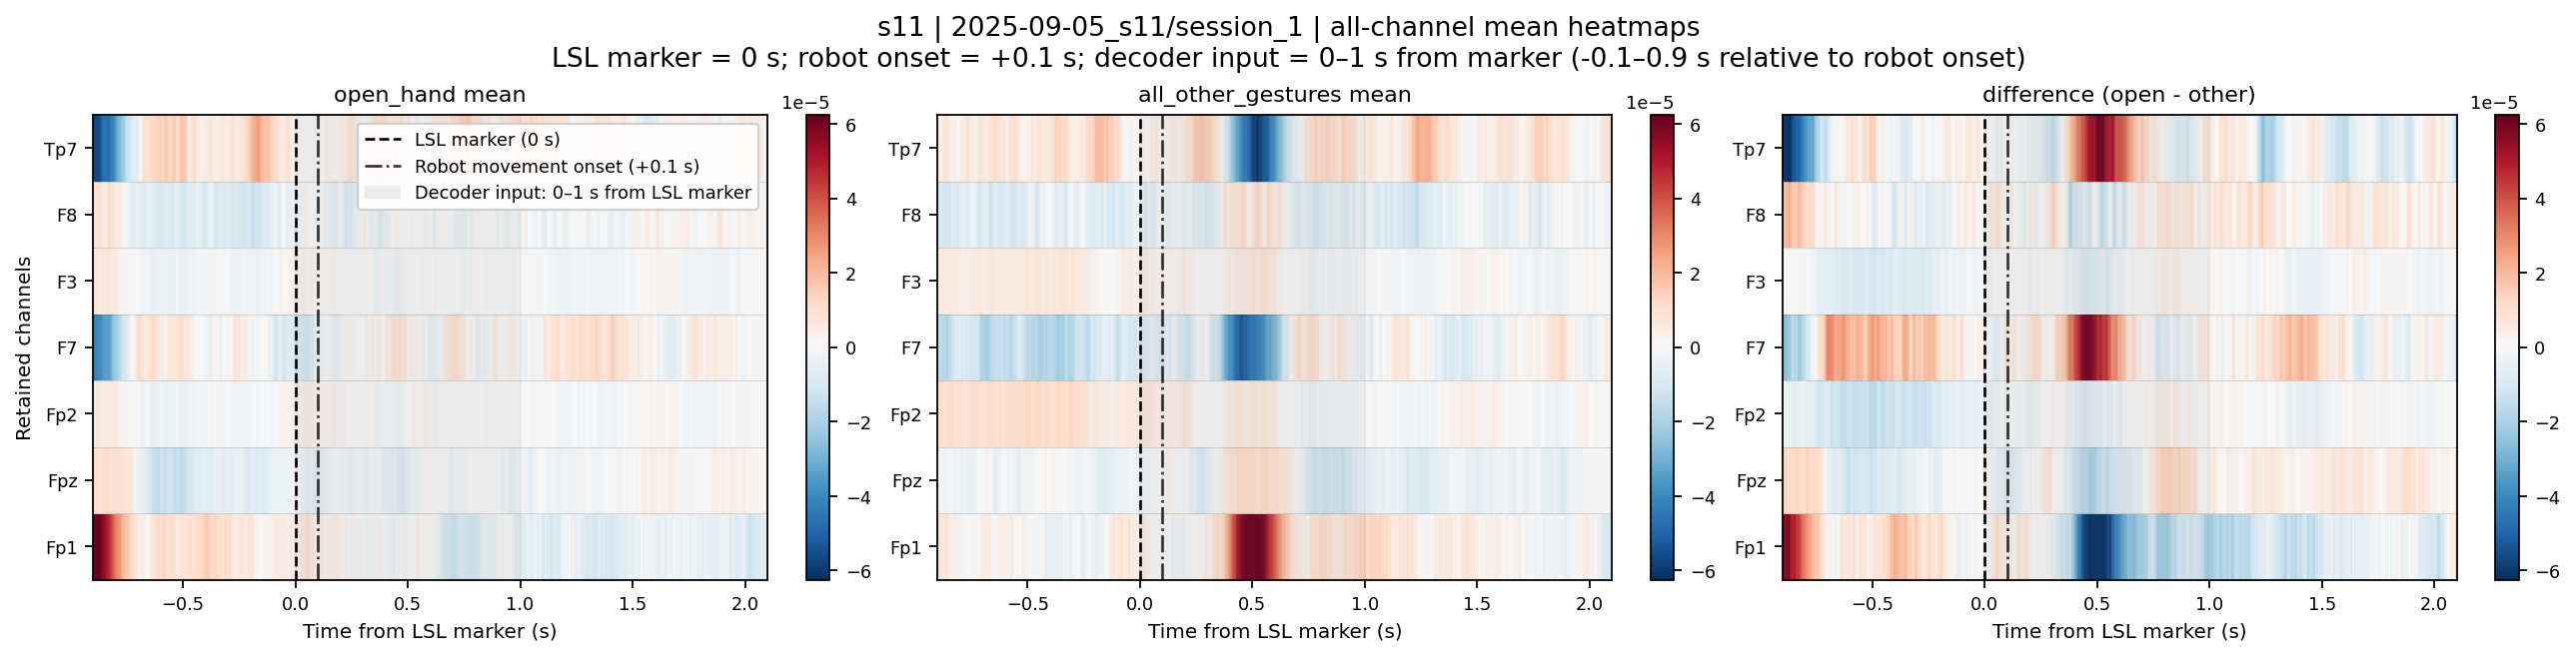

In [9]:

for obj in session_objects:
    session_name = obj['session_name']
    safe = sanitize_session_name(session_name)
    epochs = obj['epochs']

    plot_all_channel_mean_heatmaps(
        epochs, PATIENT_ID, session_name,
        DIRS['raw_session'] / f'{safe}__all_channel_mean_heatmaps'
    )
    plot_channel_overlay_grid(
        epochs, PATIENT_ID, session_name,
        DIRS['raw_session'] / f'{safe}__channel_overlay_grid'
    )

print('Saved session-level raw / ERP visualizations to:')
print(DIRS['raw_session'])

if SHOW_INLINE_PREVIEW and session_objects:
    preview_session = session_objects[0]['epochs']
    plot_all_channel_mean_heatmaps(preview_session, PATIENT_ID, session_objects[0]['session_name'], OUTPUT_ROOT / '_tmp_preview_heatmaps')
    from IPython.display import Image
    display(Image(filename=str((OUTPUT_ROOT / '_tmp_preview_heatmaps').with_suffix('.png'))))


## 5. Расширенные настройки v3

In [10]:

from matplotlib.patches import Rectangle
from scipy.stats import rankdata

# Фактический decoder window — относительно LSL marker.
DECODER_TMIN_MARKER = 0.0
DECODER_TMAX_MARKER = 1.0
DECODER_FMIN = 0.1
DECODER_FMAX = 59.4

# Начало движения робота находится на +100 ms относительно LSL marker.
# Эти значения нужны только для текстового пояснения; графики строятся
# в координатах LSL marker, чтобы decoder window начинался ровно в 0 s.
ROBOT_ONSET_MARKER_TIME = ROBOT_DELAY_S
DECODER_TMIN_ROBOT = DECODER_TMIN_MARKER - ROBOT_DELAY_S
DECODER_TMAX_ROBOT = DECODER_TMAX_MARKER - ROBOT_DELAY_S

# Baseline текущего preprocessing — относительно LSL marker.
PIPELINE_BASELINE_MARKER = (-0.1, 0.0)

# TFR для средних картинок.
V3_TFR_FMIN = 0.1
V3_TFR_FMAX = 120.0
V3_TFR_N_FREQS = 100
V3_TFR_DECIM = 2

# TFR для количественной различимости: более сильный decim ради памяти.
DISC_FMIN = 0.1
DISC_FMAX = 120.0
DISC_N_FREQS = 80
DISC_DECIM = 10
COMPUTE_AUC = True
AUC_FEATURE_CHUNK = 4000

# Тяжёлые блоки можно отключать отдельно.
RUN_PER_GESTURE_TFR_ABSOLUTE = True
RUN_PER_GESTURE_TFR_PIPELINE = True
RUN_DISCRIMINABILITY = True

V3_DIRS = {
    'meta': ensure_dir(OUTPUT_ROOT / '10_v3_metadata'),
    'tfr_absolute': ensure_dir(OUTPUT_ROOT / '11_tfr_absolute_log_power'),
    'tfr_pipeline': ensure_dir(OUTPUT_ROOT / '12_tfr_pipeline_baseline'),
    'per_gesture_raw': ensure_dir(OUTPUT_ROOT / '13_per_gesture_raw'),
    'per_gesture_tfr_absolute': ensure_dir(OUTPUT_ROOT / '14_per_gesture_tfr_absolute'),
    'per_gesture_tfr_pipeline': ensure_dir(OUTPUT_ROOT / '15_per_gesture_tfr_pipeline'),
    'discriminability': ensure_dir(OUTPUT_ROOT / '16_discriminability'),
    'candidates': ensure_dir(OUTPUT_ROOT / '17_candidate_panels'),
}

print('Decoder window relative to LSL marker:',
      (DECODER_TMIN_MARKER, DECODER_TMAX_MARKER))
print('The same window relative to robot onset:',
      (DECODER_TMIN_ROBOT, DECODER_TMAX_ROBOT))
print('LSL marker: 0.0 s; robot movement onset:', ROBOT_ONSET_MARKER_TIME, 's')
print('Pipeline baseline relative to marker:', PIPELINE_BASELINE_MARKER)
print('Pipeline baseline relative to robot onset:',
      (PIPELINE_BASELINE_MARKER[0] - ROBOT_DELAY_S,
       PIPELINE_BASELINE_MARKER[1] - ROBOT_DELAY_S))

Decoder window relative to LSL marker: (0.0, 1.0)
The same window relative to robot onset: (-0.1, 0.9)
LSL marker: 0.0 s; robot movement onset: 0.1 s
Pipeline baseline relative to marker: (-0.1, 0.0)
Pipeline baseline relative to robot onset: (-0.2, -0.1)


## 6. Подробные события: десять отдельных жестов

In [11]:

def gesture_name_from_annotation(description: str, event_code: int) -> str:
    text = str(description)
    if text.startswith('LSL '):
        text = text[4:]
    text = text.strip().replace(' ', '_')
    return text or f'event_{event_code}'


def get_epoch_data_by_codes(epochs: mne.Epochs, codes) -> np.ndarray:
    mask = np.isin(epochs.events[:, 2], list(codes))
    return epochs.get_data()[mask]


def build_detailed_epochs_for_session(session_df: pd.DataFrame):
    rows = session_df[
        (session_df['accepted_after_rejection'] == True)
        & (session_df['included_in_main_task'] == True)
        & (session_df['event_code'].isin([1,2,3,4,5,6,7,8,9,10]))
    ].copy()
    rows = rows.sort_values(['sample', 'annotation_index']).reset_index(drop=True)

    if rows.empty:
        raise RuntimeError('No accepted task epochs in session.')

    edf_path = Path(rows['edf_path'].iloc[0])
    if not edf_path.exists():
        derived = DATA_ROOT / str(rows['session'].iloc[0]) / edf_path.name
        if derived.exists():
            edf_path = derived
        else:
            candidates = list((DATA_ROOT / str(rows['session'].iloc[0])).glob('*.edf'))
            if len(candidates) == 1:
                edf_path = candidates[0]
            else:
                raise FileNotFoundError(edf_path)

    retained_channels = split_retained_channels(rows['retained_channels'].iloc[0])
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw = preprocess_raw_for_retained_channels(raw, retained_channels)

    events = np.zeros((len(rows), 3), dtype=int)
    events[:, 0] = rows['sample'].astype(int).to_numpy()
    events[:, 2] = rows['event_code'].astype(int).to_numpy()

    code_to_name = {}
    for code in sorted(rows['event_code'].unique()):
        desc = rows.loc[rows['event_code'] == code, 'annotation_description'].iloc[0]
        code_to_name[int(code)] = gesture_name_from_annotation(desc, int(code))

    event_id = {name: code for code, name in code_to_name.items()}
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=EPOCH_TMIN_MARKER,
        tmax=EPOCH_TMAX_MARKER,
        baseline=None,
        preload=True,
        event_repeated='drop',
        verbose='ERROR',
    )
    return epochs, rows, code_to_name


detailed_session_objects = []
for session_name in patient_sessions:
    session_df = patient_manifest[patient_manifest['session'] == session_name].copy()
    epochs, rows, code_to_name_session = build_detailed_epochs_for_session(session_df)
    detailed_session_objects.append({
        'session_name': session_name,
        'epochs': epochs,
        'rows': rows,
        'code_to_name': code_to_name_session,
    })
    print(session_name, len(epochs), 'epochs')

channel_orders = [tuple(obj['epochs'].ch_names) for obj in detailed_session_objects]
if len(set(channel_orders)) != 1:
    raise RuntimeError('Retained channels differ between sessions; aggregate analysis is unsafe.')

detailed_epochs = mne.concatenate_epochs(
    [obj['epochs'] for obj in detailed_session_objects],
    add_offset=True,
)
code_to_name = detailed_session_objects[0]['code_to_name']

print('Aggregated detailed epochs:', len(detailed_epochs))
for code, name in code_to_name.items():
    print(code, name, int(np.sum(detailed_epochs.events[:, 2] == code)))


2025-09-05_s11/session_1 135 epochs
2025-09-05_s11/session_2 400 epochs
Not setting metadata
535 matching events found
No baseline correction applied
Aggregated detailed epochs: 535
1 finger_flextion_index 26
2 finger_flextion_middle 29
3 finger_flextion_pinky 32
4 finger_flextion_ring 31
5 fist_clenching 30
6 index_middle_pinch 30
7 index_pinch 29
8 middle_pinch 30
9 open_hand 268
10 thumb_flextion 30


/tmp/ipykernel_2015749/2589239253.py:81: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  detailed_epochs = mne.concatenate_epochs(


## 7. Количество эпох по отдельным жестам

In [12]:

gesture_counts = pd.DataFrame([
    {
        'event_code': code,
        'gesture_name': name,
        'n_epochs': int(np.sum(detailed_epochs.events[:, 2] == code)),
        'binary_class': 'open_hand' if code == 9 else 'all_other_gestures',
    }
    for code, name in code_to_name.items()
]).sort_values('event_code')

gesture_counts.to_csv(
    V3_DIRS['meta'] / f'{PATIENT_ID}__gesture_counts.csv',
    index=False,
)
display(gesture_counts)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.bar(gesture_counts['gesture_name'], gesture_counts['n_epochs'])
ax.set_ylabel('Accepted epochs')
ax.set_title(f'{PATIENT_ID} | accepted epochs by gesture')
ax.tick_params(axis='x', rotation=45)
save_figure(fig, V3_DIRS['meta'] / f'{PATIENT_ID}__gesture_counts')


,event_code,gesture_name,n_epochs,binary_class
0,1,finger_flextion_index,26,all_other_gestures
1,2,finger_flextion_middle,29,all_other_gestures
2,3,finger_flextion_pinky,32,all_other_gestures
3,4,finger_flextion_ring,31,all_other_gestures
4,5,fist_clenching,30,all_other_gestures
5,6,index_middle_pinch,30,all_other_gestures
6,7,index_pinch,29,all_other_gestures
7,8,middle_pinch,30,all_other_gestures
8,9,open_hand,268,open_hand
9,10,thumb_flextion,30,all_other_gestures


## 8. TFR v3: функции и decoder-window overlay

In [13]:
def add_decoder_window(ax):
    rect = Rectangle(
        (DECODER_TMIN_ROBOT, DECODER_FMIN),
        DECODER_TMAX_ROBOT - DECODER_TMIN_ROBOT,
        DECODER_FMAX - DECODER_FMIN,
        fill=False,
        edgecolor='black',
        linewidth=1.3,
        linestyle='--',
    )
    ax.add_patch(rect)


def power_to_db(x):
    eps = np.finfo(float).tiny
    return 10.0 * np.log10(np.maximum(x, eps))


def average_tfr_for_codes(epochs, codes, apply_pipeline_baseline=False):
    mask = np.isin(epochs.events[:, 2], list(codes))
    selected = epochs[mask].copy()
    if apply_pipeline_baseline:
        selected.apply_baseline(PIPELINE_BASELINE_MARKER)

    freqs = np.linspace(V3_TFR_FMIN, V3_TFR_FMAX, V3_TFR_N_FREQS)
    return mne.time_frequency.tfr_morlet(
        selected,
        freqs=freqs,
        n_cycles=freqs / 2.0,
        use_fft=True,
        return_itc=False,
        average=True,
        decim=V3_TFR_DECIM,
        n_jobs=1,
        verbose='ERROR',
    )


def robust_limit(arrays, q=0.99):
    flat = np.concatenate([np.abs(np.asarray(x)).ravel() for x in arrays])
    return float(np.quantile(flat[np.isfinite(flat)], q))


def plot_binary_tfr_pages(tfr_open, tfr_other, out_dir, mode_name):
    times = tfr_open.times
    freqs = tfr_open.freqs
    open_db = power_to_db(tfr_open.data)
    other_db = power_to_db(tfr_other.data)
    diff_db = open_db - other_db

    page_size = MAX_CHANNELS_PER_FIGURE
    n_pages = math.ceil(len(tfr_open.ch_names) / page_size)

    for page in range(n_pages):
        idxs = list(range(page * page_size, min((page + 1) * page_size, len(tfr_open.ch_names))))
        fig, axes = plt.subplots(len(idxs), 3, figsize=(15, max(3, 2.7 * len(idxs))), constrained_layout=True)
        if len(idxs) == 1:
            axes = np.expand_dims(axes, 0)

        absolute = np.concatenate([open_db[idxs].ravel(), other_db[idxs].ravel()])
        abs_vmin, abs_vmax = np.quantile(absolute, [0.01, 0.99])
        diff_v = robust_limit([diff_db[idxs]])

        for row, ch_idx in enumerate(idxs):
            panels = [
                (open_db[ch_idx], 'open_hand', 'viridis', abs_vmin, abs_vmax),
                (other_db[ch_idx], 'all_other_gestures', 'viridis', abs_vmin, abs_vmax),
                (diff_db[ch_idx], 'open - other, dB', 'RdBu_r', -diff_v, diff_v),
            ]
            for col, (arr, title, cmap, vmin, vmax) in enumerate(panels):
                ax = axes[row, col]
                im = ax.imshow(
                    arr,
                    aspect='auto',
                    origin='lower',
                    extent=[times[0], times[-1], freqs[0], freqs[-1]],
                    interpolation='nearest',
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                )
                add_event_timing_lines(ax)
                add_decoder_window(ax)
                ax.set_title(f'{tfr_open.ch_names[ch_idx]} | {title}')
                ax.set_xlabel('Time from LSL marker (s)')
                ax.set_ylabel('Frequency (Hz)')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        fig.suptitle(
            f'{PATIENT_ID} | {mode_name} | page {page+1}/{n_pages}\n'
            + timing_caption()
        )
        axes[0, 0].legend(
            handles=timing_legend_handles(include_decoder=True),
            loc='upper right',
            framealpha=0.9,
        )
        save_figure(fig, out_dir / f'{mode_name}__page_{page+1:02d}')

## 9. Две версии бинарной TFR

In [14]:

# 1) Абсолютная лог-мощность: baseline correction не применяется.
tfr_open_absolute = average_tfr_for_codes(detailed_epochs, {9}, False)
tfr_other_absolute = average_tfr_for_codes(detailed_epochs, {1,2,3,4,5,6,7,8,10}, False)
plot_binary_tfr_pages(
    tfr_open_absolute,
    tfr_other_absolute,
    V3_DIRS['tfr_absolute'],
    'absolute_log_power_no_baseline',
)

# 2) Pipeline-like: baseline correction эпох (-0.1, 0.0) относительно marker до wavelet.
tfr_open_pipeline = average_tfr_for_codes(detailed_epochs, {9}, True)
tfr_other_pipeline = average_tfr_for_codes(detailed_epochs, {1,2,3,4,5,6,7,8,10}, True)
plot_binary_tfr_pages(
    tfr_open_pipeline,
    tfr_other_pipeline,
    V3_DIRS['tfr_pipeline'],
    'pipeline_epoch_baseline',
)

print(V3_DIRS['tfr_absolute'])
print(V3_DIRS['tfr_pipeline'])


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/11_tfr_absolute_log_power
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/12_tfr_pipeline_baseline


## 10. ERP: `open_hand` против каждого отдельного жеста

In [15]:
def plot_per_gesture_erp_overlays(epochs, code_to_name, out_path):
    times = epochs.times
    means = {
        code: get_epoch_data_by_codes(epochs, {code}).mean(axis=0)
        for code in sorted(code_to_name)
    }
    v = robust_limit(list(means.values()), q=0.995)

    n_ch = len(epochs.ch_names)
    ncols = 2
    nrows = math.ceil(n_ch / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, max(4, 2.7*nrows)), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    cmap = plt.get_cmap('tab10')

    for ch_idx, ch_name in enumerate(epochs.ch_names):
        ax = axes[ch_idx]
        for color_idx, code in enumerate(sorted(code_to_name)):
            if code == 9:
                continue
            ax.plot(times, means[code][ch_idx], linewidth=0.9, alpha=0.75,
                    color=cmap(color_idx % 10), label=code_to_name[code])
        ax.plot(times, means[9][ch_idx], color='black', linewidth=2.2, label='open_hand')
        add_event_timing_lines(ax, decoder_span=True)
        ax.set_ylim(-v, v)
        ax.set_title(ch_name)
        ax.set_xlabel('Time from LSL marker (s)')
        ax.set_ylabel('Amplitude')

    for idx in range(n_ch, len(axes)):
        axes[idx].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=5)
    fig.suptitle(
        f'{PATIENT_ID} | open_hand and individual gesture ERPs\n'
        + timing_caption()
    )
    save_figure(fig, out_path)


def plot_open_minus_each_gesture_erp(epochs, code_to_name, out_dir):
    times = epochs.times
    open_mean = get_epoch_data_by_codes(epochs, {9}).mean(axis=0)
    negative_codes = [c for c in sorted(code_to_name) if c != 9]

    for ch_idx, ch_name in enumerate(epochs.ch_names):
        matrix = np.vstack([
            open_mean[ch_idx] - get_epoch_data_by_codes(epochs, {code}).mean(axis=0)[ch_idx]
            for code in negative_codes
        ])
        v = robust_limit([matrix], q=0.995)
        fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
        im = ax.imshow(
            matrix,
            aspect='auto',
            origin='lower',
            extent=[times[0], times[-1], -0.5, len(negative_codes)-0.5],
            interpolation='nearest',
            cmap='RdBu_r',
            vmin=-v,
            vmax=v,
        )
        add_event_timing_lines(ax, decoder_span=True)
        ax.set_yticks(np.arange(len(negative_codes)))
        ax.set_yticklabels([code_to_name[c] for c in negative_codes])
        ax.set_xlabel('Time from LSL marker (s)')
        ax.set_ylabel('Negative gesture')
        ax.set_title(f'{PATIENT_ID} | {ch_name} | ERP: open_hand - gesture')
        fig.colorbar(im, ax=ax, label='Amplitude difference')
        ax.legend(
            handles=timing_legend_handles(include_decoder=True),
            loc='upper right',
            framealpha=0.9,
        )
        save_figure(fig, out_dir / f'open_minus_each__{sanitize_session_name(ch_name)}')

plot_per_gesture_erp_overlays(
    detailed_epochs,
    code_to_name,
    V3_DIRS['per_gesture_raw'] / f'{PATIENT_ID}__all_gesture_erp_overlays',
)
plot_open_minus_each_gesture_erp(
    detailed_epochs,
    code_to_name,
    V3_DIRS['per_gesture_raw'],
)
print(V3_DIRS['per_gesture_raw'])

/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/13_per_gesture_raw


## 11. TFR: `open_hand − gesture_i` по каждому каналу

In [16]:

def all_gesture_average_tfr(epochs, code_to_name, apply_pipeline_baseline):
    return {
        code: average_tfr_for_codes(epochs, {code}, apply_pipeline_baseline)
        for code in sorted(code_to_name)
    }


def plot_open_minus_each_gesture_tfr(tfr_by_code, code_to_name, out_dir, mode_name):
    open_tfr = tfr_by_code[9]
    times = open_tfr.times
    freqs = open_tfr.freqs
    negative_codes = [c for c in sorted(code_to_name) if c != 9]

    for ch_idx, ch_name in enumerate(open_tfr.ch_names):
        diffs = [
            power_to_db(open_tfr.data[ch_idx]) - power_to_db(tfr_by_code[code].data[ch_idx])
            for code in negative_codes
        ]
        v = robust_limit(diffs, q=0.99)
        fig, axes = plt.subplots(3, 3, figsize=(15, 11), constrained_layout=True)
        for ax, code, diff in zip(axes.ravel(), negative_codes, diffs):
            im = ax.imshow(
                diff,
                aspect='auto',
                origin='lower',
                extent=[times[0], times[-1], freqs[0], freqs[-1]],
                interpolation='nearest',
                cmap='RdBu_r',
                vmin=-v,
                vmax=v,
            )
            add_event_timing_lines(ax)
            add_decoder_window(ax)
            ax.set_title(f'open_hand - {code_to_name[code]}')
            ax.set_xlabel('Time from LSL marker (s)')
            ax.set_ylabel('Frequency (Hz)')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        fig.suptitle(
            f'{PATIENT_ID} | {ch_name} | {mode_name}\n' + timing_caption()
        )
        axes.ravel()[0].legend(
            handles=timing_legend_handles(include_decoder=True),
            loc='upper right',
            framealpha=0.9,
        )
        save_figure(fig, out_dir / f'{mode_name}__{sanitize_session_name(ch_name)}')

if RUN_PER_GESTURE_TFR_ABSOLUTE:
    each_absolute = all_gesture_average_tfr(detailed_epochs, code_to_name, False)
    plot_open_minus_each_gesture_tfr(
        each_absolute, code_to_name,
        V3_DIRS['per_gesture_tfr_absolute'],
        'absolute_no_baseline',
    )

if RUN_PER_GESTURE_TFR_PIPELINE:
    each_pipeline = all_gesture_average_tfr(detailed_epochs, code_to_name, True)
    plot_open_minus_each_gesture_tfr(
        each_pipeline, code_to_name,
        V3_DIRS['per_gesture_tfr_pipeline'],
        'pipeline_baseline',
    )

print(V3_DIRS['per_gesture_tfr_absolute'])
print(V3_DIRS['per_gesture_tfr_pipeline'])


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/14_per_gesture_tfr_absolute
/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/15_per_gesture_tfr_pipeline


## 12. Количественные карты различимости: Cohen's d и ROC-AUC

In [17]:

def cohen_d_map(x_pos, x_neg):
    mean_pos = x_pos.mean(axis=0)
    mean_neg = x_neg.mean(axis=0)
    var_pos = x_pos.var(axis=0, ddof=1)
    var_neg = x_neg.var(axis=0, ddof=1)
    n_pos, n_neg = len(x_pos), len(x_neg)
    pooled = np.sqrt(((n_pos-1)*var_pos + (n_neg-1)*var_neg) / max(n_pos+n_neg-2, 1))
    return np.divide(mean_pos-mean_neg, pooled,
                     out=np.zeros_like(mean_pos), where=pooled > 0)


def auc_map_chunked(x, y, chunk_size=4000):
    y = np.asarray(y).astype(int)
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)
    out = np.empty(x.shape[1], dtype=float)
    for start in range(0, x.shape[1], chunk_size):
        stop = min(start + chunk_size, x.shape[1])
        ranks = rankdata(x[:, start:stop], axis=0)
        rank_sum_pos = ranks[y == 1].sum(axis=0)
        out[start:stop] = (
            rank_sum_pos - n_pos*(n_pos+1)/2.0
        ) / (n_pos*n_neg)
    return out


def compute_channel_discriminability(epochs, ch_idx):
    ep = epochs.copy().apply_baseline(PIPELINE_BASELINE_MARKER)
    data = ep.get_data()[:, ch_idx:ch_idx+1, :]
    labels = (ep.events[:, 2] == 9).astype(int)
    freqs = np.linspace(DISC_FMIN, DISC_FMAX, DISC_N_FREQS)

    power = mne.time_frequency.tfr_array_morlet(
        data,
        sfreq=ep.info['sfreq'],
        freqs=freqs,
        n_cycles=freqs/2.0,
        output='power',
        decim=DISC_DECIM,
        n_jobs=1,
    )[:, 0]
    log_power = power_to_db(power)
    d = cohen_d_map(log_power[labels == 1], log_power[labels == 0])

    auc = None
    if COMPUTE_AUC:
        flat = log_power.reshape(log_power.shape[0], -1)
        auc = auc_map_chunked(flat, labels, AUC_FEATURE_CHUNK).reshape(log_power.shape[1:])

    return {
        'times': ep.times[::DISC_DECIM],
        'freqs': freqs,
        'cohen_d': d,
        'auc': auc,
    }


def window_summary(metric, times, freqs):
    inside_t = (times >= DECODER_TMIN_MARKER) & (times <= DECODER_TMAX_MARKER)
    inside_f = (freqs >= DECODER_FMIN) & (freqs <= DECODER_FMAX)
    inside = np.outer(inside_f, inside_t)
    return {
        'inside_decoder_window': float(np.nanmean(metric[inside])),
        'outside_decoder_window': float(np.nanmean(metric[~inside])),
        'low_frequency_0_59_4': float(np.nanmean(metric[freqs <= DECODER_FMAX])),
        'high_frequency_59_4_120': float(np.nanmean(metric[freqs > DECODER_FMAX])),
    }


def plot_discriminability(results, out_dir):
    names = list(results)
    page_size = MAX_CHANNELS_PER_FIGURE
    n_pages = math.ceil(len(names) / page_size)
    for page in range(n_pages):
        subset = names[page*page_size:(page+1)*page_size]
        ncols = 2 if COMPUTE_AUC else 1
        fig, axes = plt.subplots(len(subset), ncols,
                                 figsize=(12 if ncols == 2 else 7, max(3, 2.8*len(subset))),
                                 constrained_layout=True)
        if len(subset) == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif len(subset) == 1:
            axes = np.expand_dims(axes, 0)
        elif ncols == 1:
            axes = np.expand_dims(axes, 1)

        for row, name in enumerate(subset):
            r = results[name]
            times, freqs = r['times'], r['freqs']
            d = r['cohen_d']
            v = robust_limit([d], q=0.99)
            ax = axes[row, 0]
            im = ax.imshow(d, aspect='auto', origin='lower',
                           extent=[times[0], times[-1], freqs[0], freqs[-1]],
                           interpolation='nearest', cmap='RdBu_r', vmin=-v, vmax=v)
            add_event_timing_lines(ax)
            add_decoder_window(ax)
            ax.set_title(f'{name} | Cohen d')
            ax.set_xlabel('Time from LSL marker (s)')
            ax.set_ylabel('Frequency (Hz)')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

            if COMPUTE_AUC:
                auc_strength = np.abs(r['auc'] - 0.5)
                ax = axes[row, 1]
                vmax = max(0.05, float(np.quantile(auc_strength, 0.99)))
                im = ax.imshow(auc_strength, aspect='auto', origin='lower',
                               extent=[times[0], times[-1], freqs[0], freqs[-1]],
                               interpolation='nearest', cmap='magma', vmin=0, vmax=vmax)
                add_event_timing_lines(ax)
                add_decoder_window(ax)
                ax.set_title(f'{name} | |AUC - 0.5|')
                ax.set_xlabel('Time from LSL marker (s)')
                ax.set_ylabel('Frequency (Hz)')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        fig.suptitle(
            f'{PATIENT_ID} | quantitative discriminability | page {page+1}/{n_pages}\n'
            + timing_caption()
        )
        axes[0, 0].legend(
            handles=timing_legend_handles(include_decoder=True),
            loc='upper right',
            framealpha=0.9,
        )
        save_figure(fig, out_dir / f'discriminability_page_{page+1:02d}')


def plot_aggregate_discriminability(results, out_path):
    first = next(iter(results.values()))
    times, freqs = first['times'], first['freqs']
    med_d = np.median(np.stack([np.abs(r['cohen_d']) for r in results.values()]), axis=0)
    panels = [(med_d, 'Median |Cohen d| across channels')]
    if COMPUTE_AUC:
        med_auc = np.median(np.stack([np.abs(r['auc']-0.5) for r in results.values()]), axis=0)
        panels.append((med_auc, 'Median |AUC - 0.5| across channels'))

    fig, axes = plt.subplots(1, len(panels), figsize=(7*len(panels), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, (arr, title) in zip(axes, panels):
        vmax = max(0.05, float(np.quantile(arr, 0.99)))
        im = ax.imshow(arr, aspect='auto', origin='lower',
                       extent=[times[0], times[-1], freqs[0], freqs[-1]],
                       interpolation='nearest', cmap='magma', vmin=0, vmax=vmax)
        add_event_timing_lines(ax)
        add_decoder_window(ax)
        ax.set_title(title)
        ax.set_xlabel('Time from LSL marker (s)')
        ax.set_ylabel('Frequency (Hz)')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    fig.suptitle(
        f'{PATIENT_ID} | aggregate discriminability\n' + timing_caption()
    )
    axes[0].legend(
        handles=timing_legend_handles(include_decoder=True),
        loc='upper right',
        framealpha=0.9,
    )
    save_figure(fig, out_path)

if RUN_DISCRIMINABILITY:
    discriminability = {}
    summary_rows = []
    for ch_idx, ch_name in enumerate(detailed_epochs.ch_names):
        print(f'Computing {ch_name} ({ch_idx+1}/{len(detailed_epochs.ch_names)})')
        result = compute_channel_discriminability(detailed_epochs, ch_idx)
        discriminability[ch_name] = result

        row = window_summary(np.abs(result['cohen_d']), result['times'], result['freqs'])
        row.update({'channel': ch_name, 'metric': 'abs_cohen_d'})
        summary_rows.append(row)

        if COMPUTE_AUC:
            row = window_summary(np.abs(result['auc']-0.5), result['times'], result['freqs'])
            row.update({'channel': ch_name, 'metric': 'abs_auc_minus_0_5'})
            summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(V3_DIRS['discriminability'] / f'{PATIENT_ID}__window_summary.csv', index=False)
    display(summary_df)
    plot_discriminability(discriminability, V3_DIRS['discriminability'])
    plot_aggregate_discriminability(
        discriminability,
        V3_DIRS['discriminability'] / f'{PATIENT_ID}__aggregate_discriminability',
    )
    print(V3_DIRS['discriminability'])

Computing Fp1 (1/7)
Applying baseline correction (mode: mean)
Computing Fpz (2/7)
Applying baseline correction (mode: mean)
Computing Fp2 (3/7)
Applying baseline correction (mode: mean)
Computing F7 (4/7)
Applying baseline correction (mode: mean)
Computing F3 (5/7)
Applying baseline correction (mode: mean)
Computing F8 (6/7)
Applying baseline correction (mode: mean)
Computing Tp7 (7/7)
Applying baseline correction (mode: mean)


,inside_decoder_window,outside_decoder_window,low_frequency_0_59_4,high_frequency_59_4_120,channel,metric
0,0.112681,0.085590,0.099135,0.081105,Fp1,abs_cohen_d
1,0.033313,0.025684,0.029457,0.024462,Fp1,abs_auc_minus_0_5
2,0.086233,0.073248,0.085401,0.065438,Fpz,abs_cohen_d
3,0.025937,0.021207,0.025341,0.018654,Fpz,abs_auc_minus_0_5
4,0.097173,0.071975,0.085502,0.066876,Fp2,abs_cohen_d
5,0.029571,0.021112,0.025329,0.019723,Fp2,abs_auc_minus_0_5
6,0.090102,0.069544,0.075710,0.070253,F7,abs_cohen_d
7,0.027149,0.020545,0.022517,0.020781,F7,abs_auc_minus_0_5
8,0.098965,0.072971,0.085522,0.069113,F3,abs_cohen_d
9,0.030089,0.021671,0.025669,0.020489,F3,abs_auc_minus_0_5


/trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/16_discriminability


## 13. Что смотреть в первую очередь

In [18]:

reading_order = "\n".join([
    f"1. {V3_DIRS['tfr_absolute']}",
    "   Абсолютная лог-мощность без baseline correction.",
    "",
    f"2. {V3_DIRS['tfr_pipeline']}",
    "   TFR после pipeline-like baseline correction.",
    "   Пунктирный прямоугольник — фактический decoder window.",
    "",
    f"3. {V3_DIRS['per_gesture_raw']}",
    "   ERP open_hand и девяти отдельных жестов.",
    "",
    f"4. {V3_DIRS['per_gesture_tfr_absolute']}",
    f"5. {V3_DIRS['per_gesture_tfr_pipeline']}",
    "   Проверка, не создаётся ли pooled contrast одним-двумя жестами.",
    "",
    f"6. {V3_DIRS['discriminability']}",
    "   Cohen d, AUC и численное сравнение внутри/вне decoder window.",
])
print(reading_order)
(V3_DIRS['candidates'] / f'{PATIENT_ID}__reading_order.txt').write_text(
    reading_order,
    encoding='utf-8',
)


1. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/11_tfr_absolute_log_power
   Абсолютная лог-мощность без baseline correction.

2. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/12_tfr_pipeline_baseline
   TFR после pipeline-like baseline correction.
   Пунктирный прямоугольник — фактический decoder window.

3. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/13_per_gesture_raw
   ERP open_hand и девяти отдельных жестов.

4. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/14_per_gesture_tfr_absolute
5. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/15_per_gesture_tfr_pipeline
   Проверка, не создаётся ли pooled contrast одним-двумя жестами.

6. /trinity/home/t.samsonov/notebooks/Pirogov/PreprocessedData/patient_visualization_outputs/s11/16_discriminability


1064